# Assignment 02 — Application 1: Diabetes Prediction

**Student:** _<your name>_ &nbsp;&nbsp; **ID:** _<your id>_ &nbsp;&nbsp; **Class:** _<class>_
&nbsp;&nbsp; **Date:** 2026-08-29

This notebook walks the diabetes-screening application all the way from the raw
survey CSV to a saved model that the web and mobile clients load unchanged. Its
twenty-three sections match the assignment's notebook specification and trace the
pipeline

```
Data → Understand → Clean → Represent → Learn → Evaluate → Persist → Deploy
```

Every table or chart is followed by a brief written reading of what it shows.

## 0. Header and setup

The environment is pinned and printed here so the run can be reproduced later. One
constant, `RANDOM_SEED`, seeds every random step in the notebook, and the versions of
the core libraries are logged for the report's reproducibility section.


In [1]:
import sys, platform, random, time, warnings
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("Python      :", sys.version.split()[0], "on", platform.system(), platform.release())
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib  :", matplotlib.__version__)
print("joblib      :", joblib.__version__)
print("RANDOM_SEED  =", RANDOM_SEED)

Python      : 3.14.7 on Windows 10
numpy       : 2.5.2
pandas      : 3.0.5
scikit-learn: 1.9.0
matplotlib  : 3.11.1
joblib      : 1.5.3
RANDOM_SEED  = 42


## 1. Problem definition

### 1.1 Real-world problem

Public-health programmes need a way to screen large adult populations and decide who
should be referred for a confirmatory blood test or a lifestyle-intervention
programme. At screening time there is no lab result to go on — only a short
self-reported health questionnaire. The US Centers for Disease Control and Prevention
(CDC) runs exactly this kind of questionnaire every year as part of the Behavioral
Risk Factor Surveillance System (BRFSS), a national telephone survey. From roughly
250,000 completed questionnaires, this application learns a function that flags the
respondents most likely to already have diabetes or pre-diabetes.

### 1.2 Supervised task

This is a binary **classification** problem. The input `X` is one respondent's vector
of 21 questionnaire answers, listed in section 1.3. The target `y` is
`Diabetes_binary`, built from the three-level survey label `Diabetes_012` by mapping
"no diabetes" (0) to the negative class and both "pre-diabetes" (1) and "diabetes" (2)
to the positive class.

The two positive levels are merged because they lead to the same screening action —
refer the respondent for follow-up — and because pre-diabetes alone is only about
1.8% of the data, too thin to support a reliable third class.

### 1.3 Feature dictionary

Field meanings and codings come from the UCI *CDC Diabetes Health Indicators* dataset
page (https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators), which
documents this exact file. Every column is stored as `float64`, though all but three
are integer-coded categories.

| # | Feature | Type | Coding / units | Meaning (questionnaire item) |
|---|---|---|---|---|
| — | `Diabetes_012` | target (raw) | 0 / 1 / 2 | 0 = no diabetes or gestational-only, 1 = pre-diabetes, 2 = diabetes. Collapsed to `Diabetes_binary` (0 vs {1,2}). |
| 1 | `HighBP` | binary | 0 / 1 | Ever told by a health professional that you have **high blood pressure**. |
| 2 | `HighChol` | binary | 0 / 1 | Ever told that your **blood cholesterol is high**. |
| 3 | `CholCheck` | binary | 0 / 1 | Had a **cholesterol check within the past 5 years**. |
| 4 | `BMI` | continuous | kg/m² (≈12–98 in data) | **Body-mass index**, computed by the CDC from self-reported height and weight. |
| 5 | `Smoker` | binary | 0 / 1 | Smoked **at least 100 cigarettes** in your entire life. |
| 6 | `Stroke` | binary | 0 / 1 | Ever told you **had a stroke**. |
| 7 | `HeartDiseaseorAttack` | binary | 0 / 1 | Ever had **coronary heart disease (CHD) or a myocardial infarction (MI)**. |
| 8 | `PhysActivity` | binary | 0 / 1 | Any **physical activity in the past 30 days** other than your regular job. |
| 9 | `Fruits` | binary | 0 / 1 | Eat **fruit ≥ 1 time per day**. |
| 10 | `Veggies` | binary | 0 / 1 | Eat **vegetables ≥ 1 time per day**. |
| 11 | `HvyAlcoholConsump` | binary | 0 / 1 | **Heavy drinker**: ≥ 14 drinks/week (men) or ≥ 7 drinks/week (women). |
| 12 | `AnyHealthcare` | binary | 0 / 1 | Have **any health-care coverage** (insurance, HMO, government plan, …). |
| 13 | `NoDocbcCost` | binary | 0 / 1 | In the past 12 months, **needed a doctor but could not afford one**. |
| 14 | `GenHlth` | ordinal | 1–5 | Self-rated general health: **1 = excellent, 2 = very good, 3 = good, 4 = fair, 5 = poor**. |
| 15 | `MentHlth` | count | 0–30 days | Number of days in the past 30 that **mental health was "not good"** (stress, depression, emotions). |
| 16 | `PhysHlth` | count | 0–30 days | Number of days in the past 30 that **physical health was "not good"** (illness or injury). |
| 17 | `DiffWalk` | binary | 0 / 1 | **Serious difficulty walking or climbing stairs**. |
| 18 | `Sex` | binary | 0 / 1 | **0 = female, 1 = male** (respondent's sex as recorded by BRFSS). |
| 19 | `Age` | ordinal | 1–13 bracket | 5-year **age band** (`_AGEG5YR`): 1 = 18–24, 2 = 25–29, 3 = 30–34, …, 9 = 60–64, …, 12 = 75–79, **13 = 80+**. |
| 20 | `Education` | ordinal | 1–6 | Highest schooling: 1 = none/kindergarten, 2 = grades 1–8, 3 = grades 9–11, 4 = high-school graduate/GED, 5 = some college / technical, 6 = **college graduate (4+ yrs)**. |
| 21 | `Income` | ordinal | 1–8 | Annual household income band: 1 = < \$10k, 2 = \$10–15k, 3 = \$15–20k, 4 = \$20–25k, 5 = \$25–35k, 6 = \$35–50k, 7 = \$50–75k, 8 = **≥ \$75k**. |

Four columns — `GenHlth`, `Age`, `Education` and `Income` — are ordinal codes whose
numeric order matches their real-world order (higher `GenHlth` means worse health,
higher `Age` band means older, and so on). Keeping each as a single ordered numeric
column is therefore enough to preserve what it carries, and section 10 shows each one
tracking diabetes risk monotonically. The dataset is entirely tabular — it has no
free-text field — so the text-representation part of the assignment is demonstrated
in the e-commerce notebook instead.


## 2. Dataset source

The data is the **Diabetes Health Indicators Dataset**, file
`diabetes_012_health_indicators_BRFSS2015.csv`, published on Kaggle at
https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset and also
listed as entry #891 of the UCI Machine Learning Repository
(https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators). It derives
from a United States government survey and is therefore in the public domain; the copy
used here was downloaded on 2026-08-29.

The file is a cleaned extract of the **CDC BRFSS 2015** telephone health survey. Its
author selected 21 diabetes-related indicators and released three variants of the
file; this notebook uses the three-class variant, where `Diabetes_012` distinguishes
no diabetes, pre-diabetes and diabetes. Every value is a respondent self-report; the
CDC bands several fields (age into 13 brackets, income into 8, general health into 5),
and the dataset author already dropped rows where a respondent answered "don't know"
or "refused".

The raw file sits at
`diabetes/data/diabetes_012_health_indicators_BRFSS2015.csv` — comma-separated, one
header row, every value `float64`. Row/column counts are reported in section 4, and
per-feature descriptions are in the section 1.3 table.


## 3. Dataset loading

In [2]:
CSV_PATH = "../data/diabetes_012_health_indicators_BRFSS2015.csv"   # separator: ","
df = pd.read_csv(CSV_PATH)
print("loaded:", CSV_PATH)
df.head()

loaded: ../data/diabetes_012_health_indicators_BRFSS2015.csv


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


The file loads cleanly. The leading column, `Diabetes_012`, carries the survey
label, and the remaining 21 columns are the questionnaire items described in section
1.3. Everything is already numeric, so no type conversion is needed at load time. Each
row is one adult respondent holding every answer they gave.


## 4. Dataset inspection

In [3]:
print("shape (rows, columns):", df.shape)     # <-- the dataset shape
df.info()
display(df.describe().T)
print("\nmissing values per column:\n", df.isna().sum())
print("\nexact duplicate rows:", df.duplicated().sum())
print("\nraw target Diabetes_012 counts:\n", df["Diabetes_012"].value_counts().sort_index())

shape (rows, columns): (253680, 22)


<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0



missing values per column:
 Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

exact duplicate rows: 23899

raw target Diabetes_012 counts:
 Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64


The frame has shape `(253680, 22)`: **253,680 respondents**, one per row, and
**22 columns** — the 21 questionnaire features plus the `Diabetes_012` label. Every
column is `float64`, even though all but `BMI`, `MentHlth` and `PhysHlth` are
integer-coded categories.

`isna().sum()` is zero across the board, so nothing is explicitly missing.
`duplicated().sum()` reports 23,899 rows (about 9.4%) that exactly repeat another row
— handled in section 7. The summary statistics point to two ranges worth a closer
look: `BMI` spans 12 to 98, and `MentHlth`/`PhysHlth` sit at 0 for most respondents but
run up to 30. The raw target is heavily skewed, with 213,703, 4,631 and 35,346 rows in
classes 0, 1 and 2 respectively.


## 5. Data-quality analysis

In [4]:
y_bin_preview = (df["Diabetes_012"] >= 1).astype(int)

rows = [
    ["(all columns)", "explicit NaN / missing", int(df.isna().sum().sum()),
     "none needed; keep a median imputer in the pipeline for robustness at inference"],
    ["(all rows)", "exact duplicate rows", int(df.duplicated().sum()),
     "drop before the split so no answer-vector is shared by train and test (section 7)"],
    ["BMI", "extreme values (12..98)",
     int(((df.BMI < 14) | (df.BMI > 80)).sum()),
     "examine magnitude in section 9; retain all values"],
    ["MentHlth / PhysHlth", "heavy right skew, mostly 0 (0..30 days)",
     f"{(df.MentHlth > 0).mean():.0%} / {(df.PhysHlth > 0).mean():.0%} non-zero",
     "genuine survey answers -> keep; StandardScaler handles the scale"],
    ["GenHlth/Age/Education/Income", "ordinal codes, not true numbers", "-",
     "treat as ordinal numeric (monotonic with risk) + scale"],
    ["Diabetes_012 -> Diabetes_binary", "class imbalance",
     f"{y_bin_preview.mean():.2%} positive (raw)",
     "stratified split; class_weight='balanced'; judge on F1 / recall / ROC-AUC, not accuracy"],
]
pd.DataFrame(rows, columns=["column", "issue", "count", "planned action"])

,column,issue,count,planned action
0,(all columns),explicit NaN / missing,0,none needed; keep a median imputer in the pipe...
1,(all rows),exact duplicate rows,23899,drop before the split so no answer-vector is s...
2,BMI,extreme values (12..98),306,examine magnitude in section 9; retain all values
3,MentHlth / PhysHlth,"heavy right skew, mostly 0 (0..30 days)",31% / 37% non-zero,genuine survey answers -> keep; StandardScaler...
4,GenHlth/Age/Education/Income,"ordinal codes, not true numbers",-,treat as ordinal numeric (monotonic with risk)...
5,Diabetes_012 -> Diabetes_binary,class imbalance,15.76% positive (raw),stratified split; class_weight='balanced'; jud...


The table lists every quality issue found and what will be done about it. Overall
the data is in good shape: no missing values, no free-text columns, no identifier
column, no type mismatches. Three things do need handling.

The block of exact duplicate rows is dealt with in section 7 — removing them lifts the
positive rate from about 15.8% in the raw file to about 17.3%, since the duplicates
cluster around common "healthy" answer patterns. The far end of the `BMI` range is
examined in section 9, and every value is ultimately kept. The class imbalance is
addressed through the stratified split, class weighting and metric choice covered in
sections 14, 17 and 19.

The right skew in `MentHlth` and `PhysHlth` is expected, not a defect — both simply
count "not good" days out of the last 30 — so it is treated as genuine signal rather
than something to fix.


## 6. Missing-value analysis

In [5]:
miss = df.isna().sum()
pd.DataFrame({"missing_count": miss,
             "missing_pct": (miss / len(df) * 100).round(2)})

,missing_count,missing_pct
Diabetes_012,0,0.0
HighBP,0,0.0
HighChol,0,0.0
CholCheck,0,0.0
BMI,0,0.0
Smoker,0,0.0
Stroke,0,0.0
HeartDiseaseorAttack,0,0.0
PhysActivity,0,0.0
Fruits,0,0.0


Every column reports zero missing values, so no row is dropped and no column is
removed for sparsity — there is no per-column imputation decision to make here.

Even so, the numeric branch of the section-15 pipeline opens with a
`SimpleImputer(strategy="median")`. It has nothing to do on this training data, but it
means the deployed service keeps working if a real request leaves a field blank: the
training-only median fills the gap. Carrying the imputer also keeps the training and
inference code paths identical.


## 7. Duplicate analysis

In [6]:
n_before = len(df)
n_exact = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
n_after = len(df)
print(f"exact duplicate rows removed : {n_exact}")
print(f"N before : {n_before}")
print(f"N after  : {n_after}   ({n_before - n_after} rows dropped, "
      f"{(n_before - n_after)/n_before:.2%})")

exact duplicate rows removed : 23899
N before : 253680
N after  : 229781   (23899 rows dropped, 9.42%)


The file carries no respondent identifier, so the only duplicate that can be
caught is a row that repeats another one in full — and 23,899 rows do, about 9.4% of
the data.

These rows are dropped before the train/validation/test split, for two reasons. With
21 mostly-binary columns, some identical rows will occur by chance rather than from a
respondent being logged twice, and the two situations are indistinguishable — but if
the same answer vector ends up in both train and test, the test score would be
inflated by memorisation rather than genuine generalisation. Removing the duplicates
up front also stops the most common answer patterns from being over-weighted during
training. After the drop, `N` is 229,781, and every later section works from this
de-duplicated frame.


## 8. Invalid-value analysis

In [7]:
checks = {
    "BMI < 14 (near-impossible for an ambulatory adult)": int((df.BMI < 14).sum()),
    "BMI > 80 (near-impossible for a phone respondent)":  int((df.BMI > 80).sum()),
    "BMI in 60..80 (severe obesity - plausible)":         int(df.BMI.between(60, 80).sum()),
    "MentHlth outside 0..30":                             int(((df.MentHlth < 0) | (df.MentHlth > 30)).sum()),
    "PhysHlth outside 0..30":                             int(((df.PhysHlth < 0) | (df.PhysHlth > 30)).sum()),
    "GenHlth outside 1..5":                               int(((df.GenHlth < 1) | (df.GenHlth > 5)).sum()),
    "Age bracket outside 1..13":                          int(((df.Age < 1) | (df.Age > 13)).sum()),
    "Education outside 1..6":                             int(((df.Education < 1) | (df.Education > 6)).sum()),
    "Income outside 1..8":                               int(((df.Income < 1) | (df.Income > 8)).sum()),
    "binary column not in {0,1}":                         int(sum(
        (~df[col].isin([0, 1])).sum()
        for col in ["HighBP","HighChol","CholCheck","Smoker","Stroke",
                    "HeartDiseaseorAttack","PhysActivity","Fruits","Veggies",
                    "HvyAlcoholConsump","AnyHealthcare","NoDocbcCost","DiffWalk","Sex"])),
}
pd.Series(checks, name="row_count")

BMI < 14 (near-impossible for an ambulatory adult)     27
BMI > 80 (near-impossible for a phone respondent)     279
BMI in 60..80 (severe obesity - plausible)            589
MentHlth outside 0..30                                  0
PhysHlth outside 0..30                                  0
GenHlth outside 1..5                                    0
Age bracket outside 1..13                               0
Education outside 1..6                                  0
Income outside 1..8                                     0
binary column not in {0,1}                              0
Name: row_count, dtype: int64

Each row in the check is a range test: does a column stay inside the domain its
coding allows? Every coded column passes — the 14 binary columns hold only 0 and 1,
`GenHlth` sits in 1–5, `Age` in 1–13, `Education` in 1–6, `Income` in 1–8, and both
"days" columns in 0–30.

`BMI` is the one column with values outside a plausible range. A small number of rows
sit below 14 or above 80, which is barely consistent with an adult able to complete a
phone survey, and a few hundred more sit in the 60–80 band — unusual, but consistent
with genuine severe obesity. Nothing is changed or dropped at this point; section 9
sizes up these values and concludes that all of them should be kept.


## 9. Outlier analysis

overall diabetes rate = 0.173


,BMI band,n rows,% of data,diabetes rate in band
0,BMI < 14,27,0.012,0.111
1,14 <= BMI < 40,216038,94.019,0.161
2,40 <= BMI < 60,12848,5.591,0.375
3,60 <= BMI < 80,587,0.255,0.291
4,BMI >= 80,281,0.122,0.164


IQR-rule outlier counts:
 {'BMI': 5638, 'MentHlth': 36163, 'PhysHlth': 34347}


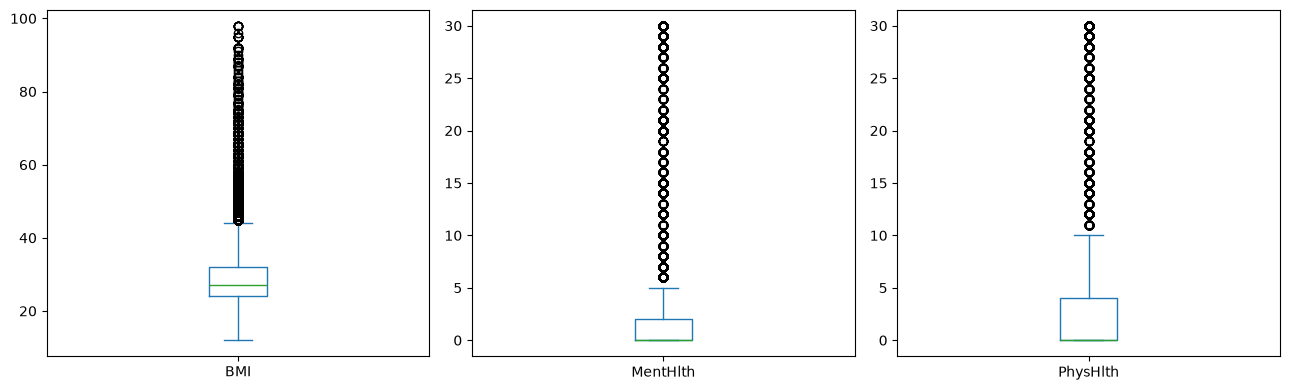

In [8]:
# 9a. how large is the BMI tail, and does it look like noise or like real high-risk people?
bins = [(df.BMI < 14, "BMI < 14"), (df.BMI.between(14, 40, inclusive="left"), "14 <= BMI < 40"),
        (df.BMI.between(40, 60, inclusive="left"), "40 <= BMI < 60"),
        (df.BMI.between(60, 80, inclusive="left"), "60 <= BMI < 80"),
        (df.BMI >= 80, "BMI >= 80")]
tail = pd.DataFrame(
    [[lbl, int(m.sum()), round(m.mean()*100, 3),
      round((df.loc[m, "Diabetes_012"] >= 1).mean(), 3)] for m, lbl in bins],
    columns=["BMI band", "n rows", "% of data", "diabetes rate in band"])
overall = (df.Diabetes_012 >= 1).mean()
print(f"overall diabetes rate = {overall:.3f}")
display(tail)

# 9b. IQR view of the three genuinely continuous columns
cont_cols = ["BMI", "MentHlth", "PhysHlth"]
Q1, Q3 = df[cont_cols].quantile(0.25), df[cont_cols].quantile(0.75)
IQR = Q3 - Q1
print("IQR-rule outlier counts:\n",
      ((df[cont_cols] < Q1 - 1.5*IQR) | (df[cont_cols] > Q3 + 1.5*IQR)).sum().to_dict())
df[cont_cols].plot(kind="box", subplots=True, layout=(1, 3), figsize=(13, 4))
plt.tight_layout(); plt.show()

The band breakdown in 9a shows the shape of the `BMI` tail. Below 14 is about
0.01% of the data. The 60–80 band is larger, roughly 0.25% of rows, and its diabetes
rate sits at or above the population average — these look like genuine severe-obesity
cases rather than data-entry noise, and dropping them would throw away real high-risk
signal. Only the rows at or above 80, and those below 14, are physiologically
questionable, and there are too few of them to move a model trained on roughly 230,000
rows.

Two facts about the later modelling make the exact treatment of this tail beside the
point. The numeric block is standardised in the pipeline, which stops the linear and
distance-based models from being dominated by a handful of large values, and the model
that ends up deployed is tree-based, so it reacts to `BMI`'s rank order rather than its
magnitude — 80 and 98 land on the same side of every split either way. Appendix A backs
this up directly: keeping, clipping, or dropping the extreme `BMI` rows all yield the
same validation metrics.

For `MentHlth` and `PhysHlth`, the IQR rule flags the many respondents reporting a
large count of "not good" days, up to the 30-day ceiling. That's a legitimate answer,
not an error, so both columns are left untouched and `StandardScaler` brings them onto
a comparable footing. De-duplication in section 7 remains the only change made to the
data itself.


## 10. Exploratory data analysis

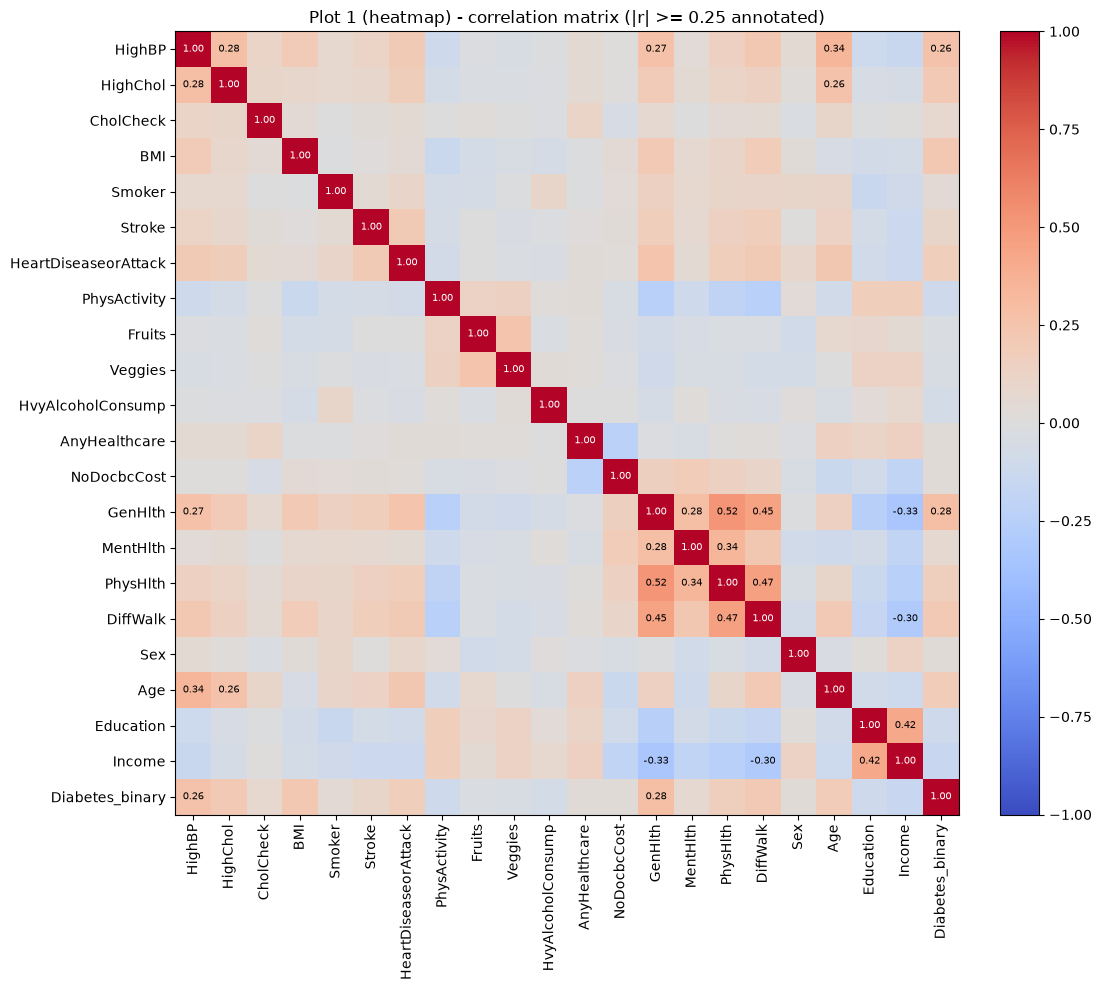

top correlations with Diabetes_binary:
Income                 -0.148
Education              -0.109
PhysActivity           -0.102
HvyAlcoholConsump      -0.066
Veggies                -0.043
Fruits                 -0.025
AnyHealthcare           0.024
NoDocbcCost             0.026
Sex                     0.031
Smoker                  0.046
MentHlth                0.059
CholCheck               0.076
Stroke                  0.098
PhysHlth                0.159
HeartDiseaseorAttack    0.167
Age                     0.185
HighChol                0.204
DiffWalk                0.208
BMI                     0.211
HighBP                  0.260
GenHlth                 0.282


In [9]:
df["Diabetes_binary"] = (df["Diabetes_012"] >= 1).astype(int)
pos_rate = df["Diabetes_binary"].mean()

# --- Plot 1: heatmap -- full correlation matrix (shown first) --------------------
corr_cols = [c for c in df.columns if c != "Diabetes_012"]      # 21 features + Diabetes_binary
C = df[corr_cols].corr()

fig, axc = plt.subplots(figsize=(12, 10))
im = axc.imshow(C.values, cmap="coolwarm", vmin=-1, vmax=1)
axc.set_xticks(range(len(corr_cols))); axc.set_xticklabels(corr_cols, rotation=90)
axc.set_yticks(range(len(corr_cols))); axc.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = C.values[i, j]
        if abs(v) >= 0.25:
            axc.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                     color="white" if abs(v) > 0.6 else "black")
axc.set_title("Plot 1 (heatmap) - correlation matrix (|r| >= 0.25 annotated)")
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

print("top correlations with Diabetes_binary:")
print(C["Diabetes_binary"].drop("Diabetes_binary").sort_values().round(3).to_string())


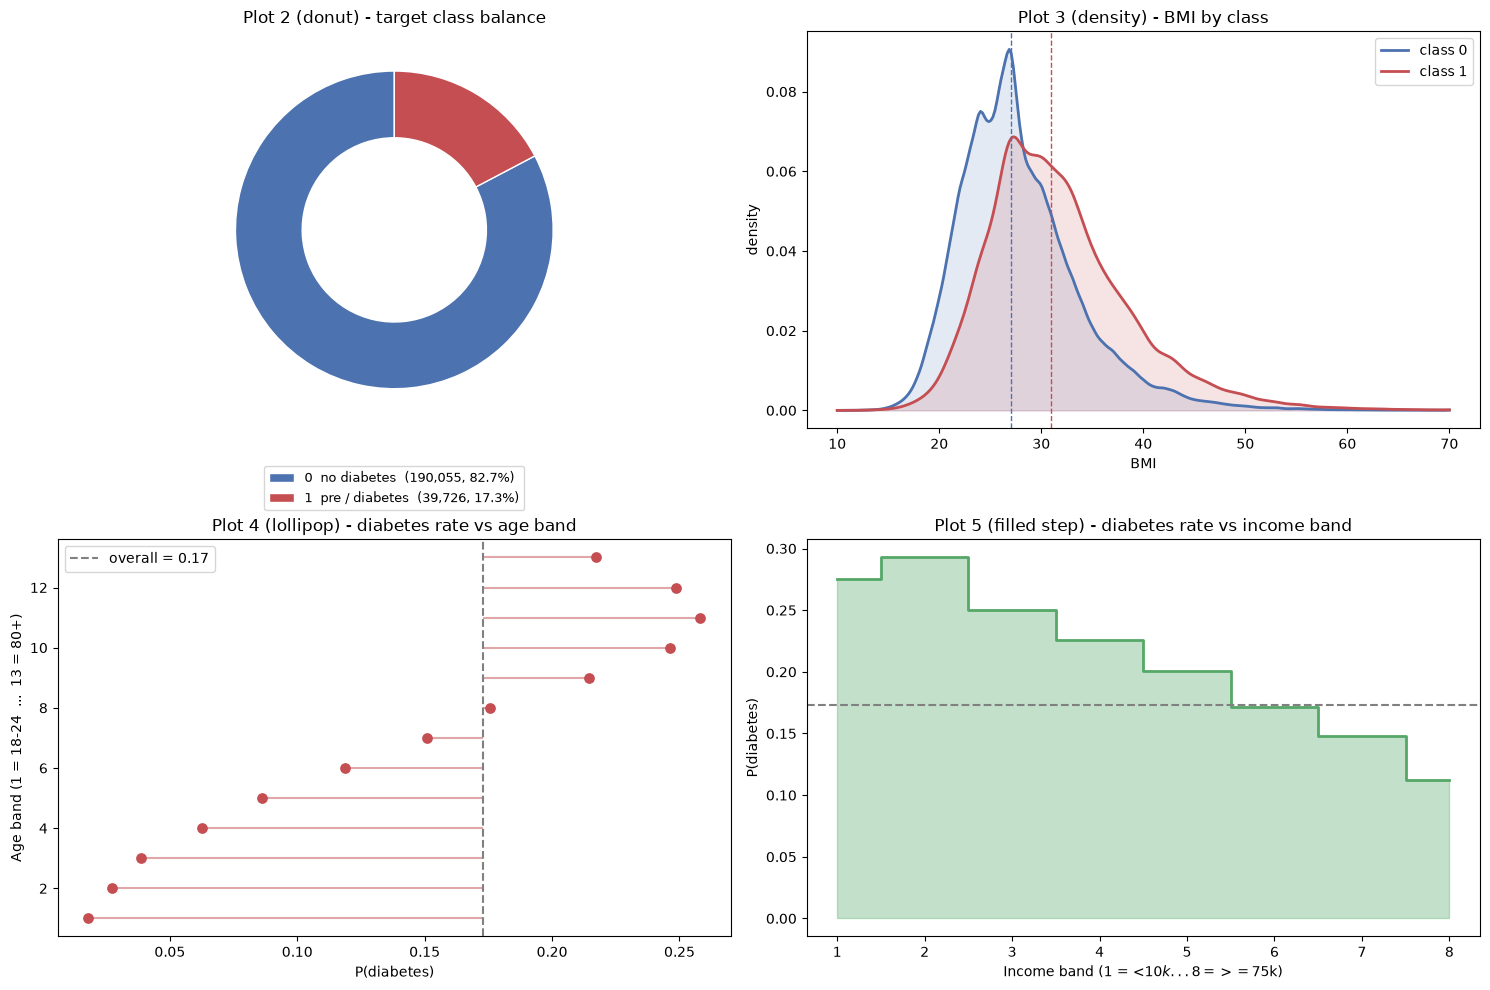

In [10]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# --- Plot 2: donut -- target class balance ----------------------------------
vc = df["Diabetes_binary"].value_counts().sort_index()
wedges, _ = ax[0, 0].pie(vc.values, colors=["#4c72b0", "#c44e52"], startangle=90,
                         wedgeprops=dict(width=0.42, edgecolor="white"))
ax[0, 0].legend(wedges, [f"0  no diabetes  ({vc[0]:,}, {vc[0]/len(df):.1%})",
                        f"1  pre / diabetes  ({vc[1]:,}, {vc[1]/len(df):.1%})"],
               loc="center", bbox_to_anchor=(0.5, -0.15), fontsize=9)
ax[0, 0].set_title("Plot 2 (donut) - target class balance")

# --- Plot 3: overlaid density -- BMI distribution per class -----------------
bmi0 = df.loc[df.Diabetes_binary == 0, "BMI"]
bmi1 = df.loc[df.Diabetes_binary == 1, "BMI"]
xs = np.linspace(10, 70, 300)
for vals, colr, lbl in [(bmi0, "#4c72b0", "class 0"), (bmi1, "#c44e52", "class 1")]:
    dens = gaussian_kde(vals)(xs)
    ax[0, 1].plot(xs, dens, color=colr, lw=2, label=lbl)
    ax[0, 1].fill_between(xs, dens, color=colr, alpha=0.15)
ax[0, 1].axvline(bmi0.median(), color="#4c72b0", ls="--", lw=1)
ax[0, 1].axvline(bmi1.median(), color="#c44e52", ls="--", lw=1)
ax[0, 1].set_xlabel("BMI"); ax[0, 1].set_ylabel("density"); ax[0, 1].legend()
ax[0, 1].set_title("Plot 3 (density) - BMI by class")

# --- Plot 4: lollipop -- diabetes rate across the ordinal Age band ----------
age_rate = df.groupby("Age")["Diabetes_binary"].mean()
ax[1, 0].hlines(age_rate.index, pos_rate, age_rate.values, color="#c44e52", alpha=0.5, lw=1.5)
ax[1, 0].scatter(age_rate.values, age_rate.index, color="#c44e52", s=45, zorder=3)
ax[1, 0].axvline(pos_rate, ls="--", c="grey", label=f"overall = {pos_rate:.2f}")
ax[1, 0].set_ylabel("Age band (1 = 18-24  ...  13 = 80+)")
ax[1, 0].set_xlabel("P(diabetes)"); ax[1, 0].legend()
ax[1, 0].set_title("Plot 4 (lollipop) - diabetes rate vs age band")

# --- Plot 5: filled step -- diabetes rate across income band ---------------
inc_rate = df.groupby("Income")["Diabetes_binary"].mean()
ax[1, 1].fill_between(inc_rate.index, inc_rate.values, step="mid", color="#55a868", alpha=0.35)
ax[1, 1].step(inc_rate.index, inc_rate.values, where="mid", color="#55a868", lw=2)
ax[1, 1].axhline(pos_rate, ls="--", c="grey")
ax[1, 1].set_xticks(inc_rate.index)
ax[1, 1].set_xlabel("Income band (1 = <$10k  ...  8 = >=$75k)")
ax[1, 1].set_ylabel("P(diabetes)")
ax[1, 1].set_title("Plot 5 (filled step) - diabetes rate vs income band")

plt.tight_layout(); plt.show()


Five figures follow, across five different chart types. Each is read the same
way: what the figure shows, what that means, and what follows for the model.

**Plot 1 — correlation matrix (heatmap).** *Observation.* The features most correlated
with `Diabetes_binary` are `GenHlth` (r ≈ 0.28), `HighBP` (≈ 0.26), `BMI` (≈ 0.21),
`DiffWalk` (≈ 0.21), `HighChol` (≈ 0.20) and `Age` (≈ 0.19); `Income`, `Education` and
`PhysActivity` are the strongest negative correlates. Among the features themselves the
largest pairing is `GenHlth`–`PhysHlth` (r ≈ 0.52), then `PhysHlth`–`DiffWalk`
(≈ 0.47) and `Income`–`Education` (≈ 0.42). *Interpretation.* Several health-burden
variables move together, but no pair comes close to collinear (all |r| < 0.6), so
nothing here is redundant. *Implication.* Linear models can use the full feature set
without dropping anything, and tree ensembles will spread importance across the
correlated group. The three strongest single correlates also define the small
reference model used in section 16.

**Plot 2 — target class balance (donut chart).** *Observation.* After de-duplication
there are about 190,055 negative rows and about 39,726 positive rows.
*Interpretation.* Roughly 17.3% of respondents are positive, so predicting the
majority class for everyone would already reach about 0.83 accuracy on its own.
*Implication.* Accuracy is set aside as the headline metric; the split is stratified,
the models use `class_weight="balanced"`, and F1, recall and ROC-AUC drive the
comparison instead.

**Plot 3 — BMI by class (overlaid density curves).** *Observation.* The positive
class's density sits noticeably higher, with a median `BMI` near 31 against about 27
for the negative class, and a longer upper tail — but the two curves overlap over most
of their range. *Interpretation.* `BMI` carries a genuine, broadly monotonic signal but
cannot separate the classes by itself. *Implication.* `BMI` is kept and standardised,
expected to rank among the more useful features without being decisive on its own.

**Plot 4 — diabetes rate against age band (lollipop chart).** *Observation.* The
positive rate climbs steadily from about 2% in band 1 (ages 18–24) to a plateau near
25% around bands 10–11 (ages 65–74), then eases slightly for the 80+ band.
*Interpretation.* Age behaves as a strong ordinal risk factor that is close to linear
across most of its range. *Implication.* `Age` can be passed in as a single ordinal
numeric column; a linear model captures most of the trend, and a tree model can also
represent the plateau and the late dip.

**Plot 5 — diabetes rate against income band (filled step chart).** *Observation.*
There is a clean negative gradient, from about 28% positive in the lowest income band
down to about 11% in the highest. *Interpretation.* Income stands in for diet,
environment and access to care, and stays informative despite not being a clinical
measurement. *Implication.* `Income` is kept as an ordinal numeric column; the pattern
it captures is socio-economic rather than mechanical, worth flagging for a fairness
discussion but not something that changes the pipeline.


## 11. Feature types

In [11]:
BINARY_FEATURES = ["HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
                   "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
                   "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost",
                   "DiffWalk", "Sex"]
ORDINAL_FEATURES = ["GenHlth", "Age", "Education", "Income"]
CONTINUOUS_FEATURES = ["BMI", "MentHlth", "PhysHlth"]
RAW_FEATURES = BINARY_FEATURES + ORDINAL_FEATURES + CONTINUOUS_FEATURES   # 21

roles = {c: "binary (0/1)" for c in BINARY_FEATURES}
roles.update({c: "ordinal categorical (coded, monotonic)" for c in ORDINAL_FEATURES})
roles.update({c: "continuous numeric" for c in CONTINUOUS_FEATURES})
roles["Diabetes_012"] = "raw survey label (dropped after deriving the target)"
roles["Diabetes_binary"] = "TARGET (binary)"
print("raw input features d_raw =", len(RAW_FEATURES))
pd.Series(roles, name="role").loc[list(df.columns)]

raw input features d_raw = 21


Diabetes_012            raw survey label (dropped after deriving the t...
HighBP                                                       binary (0/1)
HighChol                                                     binary (0/1)
CholCheck                                                    binary (0/1)
BMI                                                    continuous numeric
Smoker                                                       binary (0/1)
Stroke                                                       binary (0/1)
HeartDiseaseorAttack                                         binary (0/1)
PhysActivity                                                 binary (0/1)
Fruits                                                       binary (0/1)
Veggies                                                      binary (0/1)
HvyAlcoholConsump                                            binary (0/1)
AnyHealthcare                                                binary (0/1)
NoDocbcCost                           

The 21 input features split into 14 binary indicators, 4 ordinal codes and 3
continuous numerics. The one target is `Diabetes_binary`, derived from `Diabetes_012`.

`Diabetes_012` is dropped from the feature set once the target is built — keeping it
would hand the model the answer directly. There is no identifier column, no text
column and no constant column to remove beyond that. The four ordinal codes stay as
single numeric columns for the reasons given in sections 1.3 and 10.


## 12. Data representation

This section ties the notebook back to Lecture 02 explicitly. A tabular sample is a
vector $x = [x_1, \dots, x_d]^\top \in \mathbb{R}^d$, and the dataset as a whole is a
matrix $X \in \mathbb{R}^{N \times d}$. The path from file to model input is

```
CSV  ->  DataFrame  ->  clean feature matrix  ->  scaled matrix  ->  model input
```

The cell below prints one raw record next to the feature vector it turns into, and
reports the DataFrame's shape, the final `X` shape and its dtype — the figures used in
the report's data-representation summary.


In [12]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

def engineer(frame: pd.DataFrame) -> pd.DataFrame:
    # Deterministic, stateless feature step - applied identically in training and inference.
    # No BMI clipping (decision in section 9) - the only cleaning was the section 7 duplicate drop.
    out = frame.copy()
    out["TotalUnhealthyDays"] = (out["MentHlth"] + out["PhysHlth"]).clip(0, 60)
    out["CardioRisk"] = ((out["Stroke"] == 1) |
                         (out["HeartDiseaseorAttack"] == 1)).astype(int)
    return out

MODEL_FEATURES = RAW_FEATURES + ["TotalUnhealthyDays", "CardioRisk"]             # d = 23
SCALE_FEATURES = CONTINUOUS_FEATURES + ORDINAL_FEATURES + ["TotalUnhealthyDays"] # 8
PASS_FEATURES  = BINARY_FEATURES + ["CardioRisk"]                               # 15

raw_row = df.iloc[0][RAW_FEATURES]
print("one RAW csv record (21 features):")
print(raw_row.to_dict())

demo_X = engineer(df)[MODEL_FEATURES]
demo_pre = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), SCALE_FEATURES),
    ("bin", "passthrough", PASS_FEATURES),
])
demo_mat = demo_pre.fit_transform(demo_X)   # demo only - real fit is on the train split (section 15)

print("\nsame record as a FEATURE VECTOR x  (8 scaled + 15 passthrough), x in R^23:")
print(np.round(demo_mat[0], 3))
print("\noriginal DataFrame shape :", df.shape,
      "  # (N rows, 23 cols = Diabetes_012 + 21 raw features + derived Diabetes_binary)")
print("feature matrix X shape   :", demo_mat.shape, "  # X in R^{N x d}, d = 23")
print("target vector y shape    :", df["Diabetes_binary"].shape, "  # y in {0,1}^N")
print("dtype of X               :", demo_mat.dtype, "  # dense float64 ndarray")
print("one API request is       :  R^{1 x 23}   # a single feature vector")

one RAW csv record (21 features):
{'HighBP': 1.0, 'HighChol': 1.0, 'CholCheck': 1.0, 'Smoker': 1.0, 'Stroke': 0.0, 'HeartDiseaseorAttack': 0.0, 'PhysActivity': 0.0, 'Fruits': 0.0, 'Veggies': 1.0, 'HvyAlcoholConsump': 0.0, 'AnyHealthcare': 1.0, 'NoDocbcCost': 0.0, 'DiffWalk': 1.0, 'Sex': 0.0, 'GenHlth': 5.0, 'Age': 9.0, 'Education': 4.0, 'Income': 3.0, 'BMI': 40.0, 'MentHlth': 18.0, 'PhysHlth': 15.0}



same record as a FEATURE VECTOR x  (8 scaled + 15 passthrough), x in R^23:
[ 1.667  1.879  1.141  2.253  0.295 -0.988 -1.381  1.806  1.     1.
  1.     1.     0.     0.     0.     0.     1.     0.     1.     0.
  1.     0.     0.   ]

original DataFrame shape : (229781, 23)   # (N rows, 23 cols = Diabetes_012 + 21 raw features + derived Diabetes_binary)
feature matrix X shape   : (229781, 23)   # X in R^{N x d}, d = 23
target vector y shape    : (229781,)   # y in {0,1}^N
dtype of X               : float64   # dense float64 ndarray
one API request is       :  R^{1 x 23}   # a single feature vector


`X` is the dense array handed to `model.fit(X, y)` and `model.predict(X)`, with
shape `(N, d)` and `d = 23`. The three continuous columns, the four ordinal codes and
the engineered day-count are median-imputed and then standardised to mean 0 and
standard deviation 1; the 14 binary indicators plus the engineered `CardioRisk` flag
are already 0/1 and pass through untouched. Three things separate this array from the
raw CSV: `Diabetes_012` is gone, two engineered columns are added, and the numeric
block is scaled. Nothing is clipped and no row is dropped.

No one-hot encoding appears anywhere, since every input is already numeric or ordinal.
Scaling applies to the eight-column numeric block via `StandardScaler`, keeping
logistic regression, the support-vector machine and k-nearest-neighbours from being
dominated by `BMI`'s comparatively wide raw range.


## 13. Feature engineering

In [13]:
eng = engineer(df)
print("engineered columns added : ['TotalUnhealthyDays', 'CardioRisk']")
print("BMI left unchanged       : min =", eng.BMI.min(), " max =", eng.BMI.max())
print()
print("final model feature list (d = %d):" % len(MODEL_FEATURES))
for i, f in enumerate(MODEL_FEATURES, 1):
    tag = "scale" if f in SCALE_FEATURES else "passthrough"
    print(f"  {i:2d}. {f:22s} [{tag}]")

engineered columns added : ['TotalUnhealthyDays', 'CardioRisk']
BMI left unchanged       : min = 12.0  max = 98.0

final model feature list (d = 23):
   1. HighBP                 [passthrough]
   2. HighChol               [passthrough]
   3. CholCheck              [passthrough]
   4. Smoker                 [passthrough]
   5. Stroke                 [passthrough]
   6. HeartDiseaseorAttack   [passthrough]
   7. PhysActivity           [passthrough]
   8. Fruits                 [passthrough]
   9. Veggies                [passthrough]
  10. HvyAlcoholConsump      [passthrough]
  11. AnyHealthcare          [passthrough]
  12. NoDocbcCost            [passthrough]
  13. DiffWalk               [passthrough]
  14. Sex                    [passthrough]
  15. GenHlth                [scale]
  16. Age                    [scale]
  17. Education              [scale]
  18. Income                 [scale]
  19. BMI                    [scale]
  20. MentHlth               [scale]
  21. PhysHlth            

Two columns are engineered. `TotalUnhealthyDays` sums `MentHlth` and `PhysHlth`,
capped at 60, giving the model one steadier "total burden of poor-health days" figure
instead of two skewed ones. `CardioRisk` is the logical OR of `Stroke` and
`HeartDiseaseorAttack`; each is rare alone (about 4% and 9%), so combining them yields
one denser cardiovascular-history indicator.

No categorical encoding is needed, since the dataset has no nominal variable — the
four ordinal codes are already ordered and stay numeric — and, following section 9,
`BMI` is neither clipped nor used to filter rows. The final feature count is `d = 23`:
the 21 raw features plus the two engineered ones. Because `engineer()` is a stateless
function, the deployed service can reproduce both new columns from the 21 raw inputs
alone.


## 14. Train / validation / test split &nbsp; $D = D_\text{train} \cup D_\text{val} \cup D_\text{test}$

In [14]:
from sklearn.model_selection import train_test_split

X_all = engineer(df)[MODEL_FEATURES]
y_all = df["Diabetes_binary"].astype(int)

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_all, y_all, test_size=0.30, stratify=y_all, random_state=RANDOM_SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_SEED)

for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:5s}: {len(yy):>7d} rows   positive rate = {yy.mean():.4f}")

train:  160846 rows   positive rate = 0.1729
val  :   34467 rows   positive rate = 0.1729
test :   34468 rows   positive rate = 0.1729


The data splits into roughly 70% training, 15% validation and 15% test.
Stratifying on the target keeps the overall positive rate at about 17.3% in every part,
and `random_state = 42` makes the split reproducible.

Test data must never influence training or the fitting of any preprocessing step — if
the imputer or scaler had computed its statistics from validation or test rows, the
model would carry indirect knowledge of them and the reported score would look better
than it would on genuinely new traffic. Three things guard against that here: the
exact duplicates were already removed before the split (section 7), so no answer
vector is shared across parts; the split happens before any `.fit()` call; and every
preprocessing step is fitted on `X_train` alone, then only applied to `X_val` and
`X_test`.


## 15. Preprocessing pipeline

In [15]:
def make_preprocessor():
    return ColumnTransformer(transformers=[
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale",  StandardScaler()),
        ]), SCALE_FEATURES),
        ("bin", "passthrough", PASS_FEATURES),
    ])

preprocessor = make_preprocessor()
preprocessor.fit(X_train)                      # <-- fitted on TRAIN ONLY
print("preprocessed train shape :", preprocessor.transform(X_train).shape)
print("preprocessed val shape   :", preprocessor.transform(X_val).shape)
print("scaler means (train)     :", np.round(preprocessor.named_transformers_["num"]
                                             .named_steps["scale"].mean_, 2))

preprocessed train shape : (160846, 23)
preprocessed val shape   : (34467, 23)
scaler means (train)     : [28.7   3.5   4.7   2.6   8.09  4.98  5.89  8.2 ]


Preprocessing is one `ColumnTransformer` with two branches. The numeric branch
imputes missing values with the training median and standardises the eight-column
numeric block, putting `BMI`, the `Age` band and the day-counts on equal footing for
the scale-sensitive models. The other branch passes the 15 binary indicators straight
through, since they are already 0/1.

`make_preprocessor()` hands back a fresh, unfitted object each time. Every model in
section 17 gets its own copy, fitted on the same training rows, and the copy belonging
to the chosen model is saved alongside it in section 22. The web, mobile and API
services load that already-fitted object as-is — deployment never refits a new one.


## 16. Baseline models

In [16]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

def score(model, Xv, yv):
    p = model.predict(Xv)
    pb = model.predict_proba(Xv)[:, 1]
    return dict(accuracy=accuracy_score(yv, p), precision=precision_score(yv, p),
               recall=recall_score(yv, p), f1=f1_score(yv, p),
               roc_auc=roc_auc_score(yv, pb))

# Baseline A - "no-skill" reference: always predict the majority class.
base_dummy = Pipeline([("prep", make_preprocessor()),
                       ("clf", DummyClassifier(strategy="most_frequent"))]).fit(X_train, y_train)

# Baseline B - "cheap but real" reference: logistic regression on just the 3
# strongest correlates from the section 10 heatmap (GenHlth, HighBP, BMI).
CHEAP = ["GenHlth", "HighBP", "BMI"]
base_cheap = Pipeline([
    ("prep", ColumnTransformer([("num", Pipeline([("i", SimpleImputer(strategy="median")),
                                                  ("s", StandardScaler())]),
                                 ["GenHlth", "BMI"]),
                                ("bin", "passthrough", ["HighBP"])])),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                               random_state=RANDOM_SEED)),
]).fit(X_train[CHEAP], y_train)

bl = pd.DataFrame({
    "A: DummyClassifier (majority)": score(base_dummy, X_val, y_val),
    "B: LogReg on 3 features":       score(base_cheap, X_val[CHEAP], y_val),
}).T.round(3)
bl

,accuracy,precision,recall,f1,roc_auc
A: DummyClassifier (majority),0.827,0.000,0.000,0.000,0.50
B: LogReg on 3 features,0.699,0.328,0.708,0.448,0.77


Two reference points go in before the candidate models, because each answers a
different question.

The first is a no-information baseline that always predicts the majority class. It
reaches about 0.83 accuracy while scoring 0 on both recall and F1 — it never catches a
single diabetic respondent. That's the concrete reason accuracy is set aside as the
headline metric in favour of recall, F1 and ROC-AUC: any model that can't beat this
baseline on recall and F1 has learned nothing useful, no matter its accuracy.

The second is a deliberately small model — a plain logistic regression using only the
three strongest correlates from section 10, `GenHlth`, `HighBP` and `BMI` — which
reaches a ROC-AUC of about 0.77. Beating the no-information baseline is trivial, so
this second reference sets the bar the full-size models in section 17 need to clear by
a meaningful margin; if none of them can, this three-feature model would be the more
sensible thing to ship.


## 17. Model training

Five models are trained: logistic regression, a decision tree, a random forest,
an RBF support-vector machine and k-nearest-neighbours.

The RBF support-vector machine doesn't train in reasonable time on the full
160,000-row training set, so the comparison itself runs on a shared subsample. Fitting
each candidate on a different amount of data would confound model quality with
training-set size, so every model here is trained on the same stratified 25,000-row
slice of the training split, with identical preprocessing. The model that wins this
comparison is then refitted on the full training set in section 19 before its final
evaluation on the held-out test set and persistence, so the deployed model still
benefits from every available row. Section 18 checks that the winner's ranking holds
up between the 25,000-row fit and the full-data fit.


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

SUBSAMPLE_N = 25_000
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train, y_train, train_size=SUBSAMPLE_N,
    stratify=y_train, random_state=RANDOM_SEED)      # stratified -> keeps the ~17.3% positive rate
print("common training subsample:", X_train_sub.shape,
      "| positive rate", round(y_train_sub.mean(), 4))

model_specs = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced",
                                             random_state=RANDOM_SEED),
    "DecisionTree":       DecisionTreeClassifier(max_depth=6, min_samples_leaf=50,
                                             class_weight="balanced",
                                             random_state=RANDOM_SEED),
    "RandomForest":       RandomForestClassifier(n_estimators=300, max_depth=12,
                                             min_samples_leaf=20, n_jobs=-1,
                                             class_weight="balanced_subsample",
                                             random_state=RANDOM_SEED),
    "SVM_RBF":            SVC(kernel="rbf", C=1.0, gamma="scale", probability=True,
                             class_weight="balanced", random_state=RANDOM_SEED),
    "KNN":                KNeighborsClassifier(n_neighbors=45, weights="distance"),
}

fitted = {}
for name, clf in model_specs.items():
    pipe = Pipeline([("prep", make_preprocessor()), ("clf", clf)])
    t0 = time.time(); pipe.fit(X_train_sub, y_train_sub); dt = time.time() - t0
    fitted[name] = pipe
    print(f"{name:20s} trained on 25,000 rows in {dt:6.2f}s")

common training subsample: (25000, 23) | positive rate 0.1729
LogisticRegression   trained on 25,000 rows in   0.06s
DecisionTree         trained on 25,000 rows in   0.06s


RandomForest         trained on 25,000 rows in   1.17s


SVM_RBF              trained on 25,000 rows in 118.29s
KNN                  trained on 25,000 rows in   0.03s


All five models share the same 25,000-row training sample and the same
preprocessing. Their hyperparameters:

| Model | Key hyperparameters |
|---|---|
| LogisticRegression | `max_iter=1000`, `class_weight="balanced"` |
| DecisionTree | `max_depth=6`, `min_samples_leaf=50`, `class_weight="balanced"` |
| RandomForest | `n_estimators=300`, `max_depth=12`, `min_samples_leaf=20`, `class_weight="balanced_subsample"` |
| SVM (RBF) | `C=1.0`, `gamma="scale"`, `probability=True`, `class_weight="balanced"` |
| KNN | `n_neighbors=45`, `weights="distance"` |


## 18. Model comparison

In [18]:
rows = []
for name, pipe in fitted.items():
    s = score(pipe, X_val, y_val)
    rows.append([name, s["accuracy"], s["precision"], s["recall"], s["f1"], s["roc_auc"]])
cmp = (pd.DataFrame(rows, columns=["model", "accuracy", "precision", "recall", "f1", "roc_auc"])
         .round(3).sort_values("roc_auc", ascending=False).reset_index(drop=True))
print("baseline B (3-feature LogReg) ROC-AUC for reference:",
      round(score(base_cheap, X_val[CHEAP], y_val)["roc_auc"], 3))
cmp

baseline B (3-feature LogReg) ROC-AUC for reference: 0.77


,model,accuracy,precision,recall,f1,roc_auc
0,RandomForest,0.727,0.361,0.748,0.487,0.810
1,LogisticRegression,0.716,0.352,0.760,0.481,0.804
2,SVM_RBF,0.707,0.345,0.776,0.478,0.800
3,KNN,0.830,0.550,0.104,0.174,0.790
4,DecisionTree,0.690,0.328,0.760,0.459,0.787


In [19]:
# stability check: does the winner's quality survive going from 25k -> full training data?
BEST_NAME = cmp.iloc[0]["model"]
best_full = Pipeline([("prep", make_preprocessor()),
                      ("clf", sklearn.clone(model_specs[BEST_NAME]))]).fit(X_train, y_train)
stab = pd.DataFrame({
    f"{BEST_NAME} @ 25k subsample": score(fitted[BEST_NAME], X_val, y_val),
    f"{BEST_NAME} @ full train":    score(best_full, X_val, y_val),
}).T.round(3)
print("model carried to the held-out test set:", BEST_NAME)
stab

model carried to the held-out test set: RandomForest


,accuracy,precision,recall,f1,roc_auc
RandomForest @ 25k subsample,0.727,0.361,0.748,0.487,0.810
RandomForest @ full train,0.723,0.358,0.760,0.486,0.812


The first table ranks the five models on the validation set by ROC-AUC. The
random forest leads at about 0.81, just ahead of logistic regression at about 0.80,
with the decision tree and the RBF support-vector machine close behind. All four clear
the section-16 three-feature reference (about 0.77) by a useful margin, showing that
the full feature set and the larger models are worth their extra cost.
K-nearest-neighbours is the exception: high accuracy but a recall of only about 0.10,
because `KNeighborsClassifier` has no class-weighting option, and on imbalanced data
its neighbourhoods end up dominated by the majority class, pulling it toward
predicting "no diabetes".

The second table checks the effect of selecting on a subsample. Refitting the leading
model on the full training set moves its ROC-AUC and F1 only slightly and lifts recall
by a few points. So the 25,000-row sample was adequate for ranking the models, and the
full-data refit is what section 19 evaluates and what gets persisted for deployment.


## 19. Evaluation

=== RandomForest (full-train fit) on the held-out TEST set ===
              precision    recall  f1-score   support

           0      0.929     0.723     0.813     28509
           1      0.357     0.735     0.480      5959

    accuracy                          0.725     34468
   macro avg      0.643     0.729     0.647     34468
weighted avg      0.830     0.725     0.756     34468

ROC-AUC : 0.809

confusion matrix  [[TN FP] [FN TP]]:
 [[20612  7897]
 [ 1579  4380]]


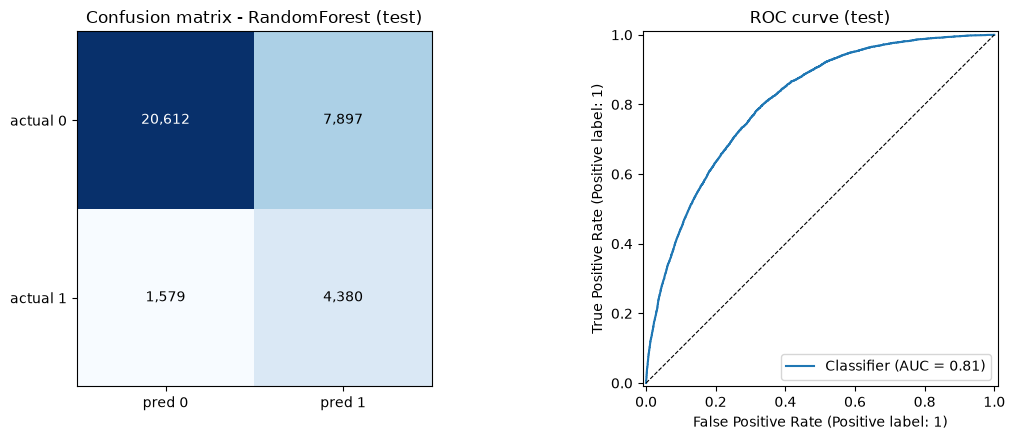

In [20]:
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay

final_pipe = Pipeline([("prep", make_preprocessor()),
                       ("clf", sklearn.clone(model_specs[BEST_NAME]))]).fit(X_train, y_train)

p_test     = final_pipe.predict(X_test)
proba_test = final_pipe.predict_proba(X_test)[:, 1]

print(f"=== {BEST_NAME} (full-train fit) on the held-out TEST set ===")
print(classification_report(y_test, p_test, digits=3))
print("ROC-AUC :", round(roc_auc_score(y_test, proba_test), 3))

cm = confusion_matrix(y_test, p_test)
print("\nconfusion matrix  [[TN FP] [FN TP]]:\n", cm)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax[0].text(j, i, f"{v:,}", ha="center", va="center",
               color="white" if v > cm.max()/2 else "black")
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["pred 0", "pred 1"])
ax[0].set_yticks([0, 1]); ax[0].set_yticklabels(["actual 0", "actual 1"])
ax[0].set_title(f"Confusion matrix - {BEST_NAME} (test)")
RocCurveDisplay.from_predictions(y_test, proba_test, ax=ax[1])
ax[1].plot([0, 1], [0, 1], "k--", lw=0.8); ax[1].set_title("ROC curve (test)")
plt.tight_layout(); plt.show()

The chosen model is evaluated exactly once, on the held-out test set, after
being refitted on the full training data.

In the confusion matrix, rows are the actual class and columns are the prediction.
Top-left is respondents correctly cleared. Top-right is respondents flagged who don't
have diabetes — each one costs a single unnecessary confirmatory test, and there are
many of them because the model leans toward recall. Bottom-left is the costly error:
respondents who do have diabetes or pre-diabetes but are predicted healthy and sent
away undiagnosed. Bottom-right is the cases correctly caught and referred.

For a population screen, missing a case (a false negative) is far more expensive than
one extra blood test (a false positive), so **recall on the positive class is the
metric that matters most**. On the test set the model reaches a recall of about 0.74 at
a precision of about 0.36, with an ROC-AUC of about 0.81 as the threshold-independent
summary. Accuracy, at about 0.72, is deliberately not treated as the headline number —
the no-information baseline in section 16 scored higher on accuracy while being
useless.


## 20. Error analysis

In [21]:
err = X_test.copy()
err["actual"] = y_test.values
err["pred"]   = p_test
err["proba"]  = proba_test.round(3)

false_neg = err[(err.actual == 1) & (err.pred == 0)]
false_pos = err[(err.actual == 0) & (err.pred == 1)]
print(f"false negatives: {len(false_neg):5d}   false positives: {len(false_pos):5d}")

summary = pd.DataFrame({
    "all_test":        X_test.assign(y=y_test.values).mean(numeric_only=True),
    "false_negatives": false_neg.mean(numeric_only=True),
    "false_positives": false_pos.mean(numeric_only=True),
}).round(2).loc[["BMI", "GenHlth", "HighBP", "HighChol", "Age",
                 "DiffWalk", "TotalUnhealthyDays", "CardioRisk"]]
display(summary)
print("\n10 most confident misses (lowest proba among false negatives):")
false_neg.sort_values("proba").head(10)

false negatives:  1579   false positives:  7897


,all_test,false_negatives,false_positives
BMI,28.64,28.23,31.11
GenHlth,2.59,2.49,3.28
HighBP,0.45,0.36,0.82
HighChol,0.44,0.36,0.70
Age,8.07,8.47,9.64
DiffWalk,0.18,0.11,0.35
TotalUnhealthyDays,8.17,5.85,11.98
CardioRisk,0.13,0.07,0.27



10 most confident misses (lowest proba among false negatives):


,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex,GenHlth,Age,Education,Income,BMI,MentHlth,PhysHlth,TotalUnhealthyDays,CardioRisk,actual,pred,proba
118312,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,5.0,8.0,26.0,5.0,0.0,5.0,0,1,0,0.024
19087,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,5.0,5.0,7.0,24.0,1.0,0.0,1.0,0,1,0,0.039
22729,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,5.0,4.0,8.0,25.0,2.0,0.0,2.0,0,1,0,0.040
212921,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,2.0,1.0,6.0,8.0,27.0,4.0,0.0,4.0,0,1,0,0.041
172633,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2.0,4.0,6.0,8.0,23.0,30.0,1.0,31.0,0,1,0,0.042
96993,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,6.0,6.0,8.0,22.0,1.0,0.0,1.0,0,1,0,0.046
200693,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,2.0,6.0,7.0,20.0,0.0,0.0,0.0,0,1,0,0.049
14669,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,8.0,6.0,8.0,21.0,1.0,5.0,6.0,0,1,0,0.051
106923,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,2.0,5.0,6.0,7.0,21.0,1.0,0.0,1.0,0,1,0,0.056
198395,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,5.0,6.0,7.0,23.0,5.0,0.0,5.0,0,1,0,0.059


Comparing the average feature values of the two error types against the test set
as a whole shows where the model struggles.

The false negatives look close to the healthy population on average: near-average
`BMI`, a low (good) `GenHlth`, and fewer `HighBP`/`DiffWalk` flags. These are diabetics
whose risk stems from factors the questionnaire never asked about — family history,
diet detail, a fasting glucose reading — so this failure is a gap in the
representation rather than a shortfall in model capacity. The false positives run the
other way: many risk markers present — high `BMI`, poor `GenHlth`, `HighBP`,
`HighChol` — without (yet) having developed diabetes. These are exactly the high-risk
non-cases a screening model is expected to over-select.

The remedies follow from that split. Closing the representation gap would take
features the survey doesn't collect, or a single lab value; alternatively, lowering
the decision threshold would trade further precision for recall wherever follow-up
capacity allows it.


## 21. Model selection

The model chosen for deployment is the **random forest**, the leader in the section-18
comparison. On the held-out test set it reaches a ROC-AUC of about 0.81, a recall of
about 0.74 and an F1 of about 0.48, clearing both baselines with room to spare.

| Criterion | Random forest (deployed) | Logistic regression (fallback) |
|---|---|---|
| Predictive performance | best ROC-AUC and best F1 in section 18 | about 0.01 ROC-AUC behind — effectively equal |
| Interpretability | feature importances and per-tree paths | signed coefficients as odds ratios, more directly readable by clinicians |
| Computational cost | trains in a few seconds; under 10 ms per prediction | trains in under a second; under 1 ms per prediction |
| Artifact size | about 55 MB pickled (300 trees) | about 30 KB pickled |
| Robustness | bagging absorbs noise and outliers, models feature interactions directly, and is insensitive to the `BMI` tail (section 9) | linear decision surface; depends on the pipeline's scaler |
| Deployment constraints | CPU-only, no dependency beyond scikit-learn | CPU-only, very small |

The random forest wins on both headline metrics without adding operational cost: the
artifact is large but loads in well under a second and serves a single request in a
few milliseconds, which is fine for a screening API. Logistic regression stays on hand
as a documented fallback — if artifact size or coefficient-level interpretability
becomes a hard requirement later, it can take over for a cost of about 0.01 ROC-AUC by
changing one line in section 22. The support-vector machine and k-nearest-neighbours
are ruled out for deployment: both were only fitted on the 25,000-row sample,
k-nearest-neighbours would have to ship the training data inside the artifact and
managed a recall of just about 0.10, and the RBF support-vector machine is the
slowest of the five at inference time.


## 22. Model persistence

In [22]:
import os, json
os.makedirs("../model", exist_ok=True)

# Refit the chosen estimator (with fresh preprocessing) on train + validation -
# all non-test data - so the deployed pipeline uses as much data as possible.
X_fit = pd.concat([X_train, X_val]);  y_fit = pd.concat([y_train, y_val])

deploy_pipe = Pipeline([("prep", make_preprocessor()),
                        ("clf",  sklearn.clone(model_specs[BEST_NAME]))])
deploy_pipe.fit(X_fit, y_fit)

joblib.dump(deploy_pipe, "../model/model_pipeline.joblib", compress=3)
joblib.dump(MODEL_FEATURES, "../model/feature_names.joblib")

schema = {
    "raw_input_features": RAW_FEATURES,
    "engineered_features": ["TotalUnhealthyDays", "CardioRisk"],
    "model_features_order": MODEL_FEATURES,
    "target": "Diabetes_binary  (0 = no diabetes, 1 = pre-diabetes or diabetes)",
    "chosen_model": BEST_NAME,
    "random_seed": RANDOM_SEED,
    "sklearn_version": sklearn.__version__,
    "feature_ranges_hint": {
        "BMI": "kg/m^2, not clipped (data range ~12..98)", "GenHlth": "1..5",
        "Age": "1..13 bracket", "Education": "1..6", "Income": "1..8",
        "MentHlth": "0..30", "PhysHlth": "0..30", "all *flag* columns": "0 or 1",
    },
}
with open("../model/input_schema.json", "w") as fh:
    json.dump(schema, fh, indent=2)

print("saved -> diabetes/model/model_pipeline.joblib")
print("saved -> diabetes/model/feature_names.joblib")
print("saved -> diabetes/model/input_schema.json")
print("pipeline steps:", [s[0] for s in deploy_pipe.steps],
      "| final estimator:", deploy_pipe.steps[-1][1].__class__.__name__)

saved -> diabetes/model/model_pipeline.joblib
saved -> diabetes/model/feature_names.joblib
saved -> diabetes/model/input_schema.json
pipeline steps: ['prep', 'clf'] | final estimator: RandomForestClassifier


For deployment the pipeline is refitted once more, this time on the training and
validation data together — every row except the held-out test set — so it makes use of
as much data as possible. Preprocessing is refitted on that same combined data, which
keeps the test set out of the fit.

Three files land in `diabetes/model/`. `model_pipeline.joblib` is a single object
holding the fitted imputer, scaler and random forest. `feature_names.joblib` is the
ordered list of 23 feature names the API must assemble before calling the pipeline.
`input_schema.json` is a human-readable contract listing the 21 raw fields, the 2
engineered fields, each field's valid range, the chosen model, the random seed and the
scikit-learn version. Nothing further is required at inference: the API loads
`model_pipeline.joblib`, rebuilds the feature frame with the same `engineer()`
function, and calls `predict_proba`.


## 23. Inference test

In [23]:
loaded_pipe     = joblib.load("../model/model_pipeline.joblib")
loaded_features = joblib.load("../model/feature_names.joblib")

def predict_one(raw: dict) -> dict:
    # raw 21-field dict -> validation -> same engineer() -> same fitted pipeline -> JSON
    missing = [k for k in RAW_FEATURES if k not in raw]
    if missing:
        raise ValueError(f"missing required fields: {missing}")
    row = engineer(pd.DataFrame([raw]))[loaded_features]   # right columns, right order
    proba = float(loaded_pipe.predict_proba(row)[0, 1])
    return {"prediction": "diabetic" if proba >= 0.5 else "not diabetic",
            "confidence": round(proba, 4)}

raw_input = {   # exactly what the web / mobile client will POST
    "HighBP": 1, "HighChol": 1, "CholCheck": 1, "BMI": 34, "Smoker": 1, "Stroke": 0,
    "HeartDiseaseorAttack": 0, "PhysActivity": 0, "Fruits": 0, "Veggies": 1,
    "HvyAlcoholConsump": 0, "AnyHealthcare": 1, "NoDocbcCost": 0, "GenHlth": 4,
    "MentHlth": 10, "PhysHlth": 15, "DiffWalk": 1, "Sex": 1, "Age": 9,
    "Education": 4, "Income": 3,
}
result = predict_one(raw_input)
print("raw input :", raw_input)
print("API output:", result)

# cross-check: raw probability from the disk artifact vs an in-memory refit
check_row       = engineer(pd.DataFrame([raw_input]))[MODEL_FEATURES]
proba_from_disk = float(loaded_pipe.predict_proba(check_row)[0, 1])
proba_in_memory = float(deploy_pipe.predict_proba(check_row)[0, 1])
print(f"\nproba from disk artifact : {proba_from_disk:.10f}")
print(f"proba from in-memory pipe: {proba_in_memory:.10f}")
assert abs(proba_from_disk - proba_in_memory) < 1e-12
print("reloaded-from-disk prediction == in-memory prediction  ->  OK")

raw input : {'HighBP': 1, 'HighChol': 1, 'CholCheck': 1, 'BMI': 34, 'Smoker': 1, 'Stroke': 0, 'HeartDiseaseorAttack': 0, 'PhysActivity': 0, 'Fruits': 0, 'Veggies': 1, 'HvyAlcoholConsump': 0, 'AnyHealthcare': 1, 'NoDocbcCost': 0, 'GenHlth': 4, 'MentHlth': 10, 'PhysHlth': 15, 'DiffWalk': 1, 'Sex': 1, 'Age': 9, 'Education': 4, 'Income': 3}
API output: {'prediction': 'diabetic', 'confidence': 0.8496}

proba from disk artifact : 0.8496260962
proba from in-memory pipe: 0.8496260962
reloaded-from-disk prediction == in-memory prediction  ->  OK


This section exercises the exact contract the web and mobile services rely on.
The pipeline is reloaded from disk as fresh objects, a single raw 21-field dictionary —
the same shape a client would POST — passes through field validation, the `engineer()`
function and the loaded pipeline, and the result comes back as

```json
{ "prediction": "diabetic", "confidence": 0.85 }
```

Nothing is fitted here — no scaler, no imputer, no model. The assertion checks that the
artifact reloaded from disk produces exactly the same probability as the in-memory
pipeline from section 22, confirming that the path `raw input → validation →
engineer() → fitted preprocessing → model → prediction` reproduces outside the
notebook.


---

## Appendix A — Sensitivity check on BMI-outlier handling

Section 9 leaves every `BMI` value unchanged. This appendix quantifies that decision —
the claim that how the extreme values are handled doesn't move model quality — and
checks the choice still holds even if some of the extreme-`BMI` respondents are
genuine. It sits apart from section 9 because it needs fitted models to answer.

On a fresh stratified split of 60,000 training rows and 20,000 held-out rows from the
de-duplicated data, a logistic regression and a random forest are fitted under four
`BMI` policies — keep everything, clip to [12, 80], clip to [14, 60], and drop rows
outside [14, 80] — and compared on ROC-AUC, F1 and recall.


In [24]:
from sklearn.linear_model import LogisticRegression as _LR
from sklearn.ensemble import RandomForestClassifier as _RF

_BIN = BINARY_FEATURES
_NUM = ["BMI", "MentHlth", "PhysHlth", "GenHlth", "Age", "Education", "Income"]
_y   = df["Diabetes_binary"].astype(int)
_Xtr, _Xte, _ytr, _yte = train_test_split(
    df[_BIN + _NUM], _y, train_size=60_000, test_size=20_000,
    stratify=_y, random_state=RANDOM_SEED)

def _prep():
    return ColumnTransformer([
        ("num", Pipeline([("i", SimpleImputer(strategy="median")),
                          ("s", StandardScaler())]), _NUM),
        ("bin", "passthrough", _BIN)])

policies = {
    "keep all BMI (chosen)": None,
    "clip BMI [12, 80]":     (12, 80),
    "clip BMI [14, 60]":     (14, 60),
    "drop BMI<14 or >80":    "drop",
}
rows = []
for label, pol in policies.items():
    if pol == "drop":
        keep = _Xtr.BMI.between(14, 80)
        Xtr_v, ytr_v, Xte_v = _Xtr[keep], _ytr[keep], _Xte
    elif pol is None:
        Xtr_v, ytr_v, Xte_v = _Xtr, _ytr, _Xte
    else:
        Xtr_v, ytr_v = _Xtr.assign(BMI=_Xtr.BMI.clip(*pol)), _ytr
        Xte_v = _Xte.assign(BMI=_Xte.BMI.clip(*pol))
    for mname, m in [("LogReg", _LR(max_iter=1000, class_weight="balanced",
                                    random_state=RANDOM_SEED)),
                     ("RandomForest", _RF(n_estimators=150, max_depth=12,
                                          min_samples_leaf=20, n_jobs=-1,
                                          class_weight="balanced_subsample",
                                          random_state=RANDOM_SEED))]:
        p = Pipeline([("prep", _prep()), ("clf", m)]).fit(Xtr_v, ytr_v)
        s = score(p, Xte_v, _yte)
        rows.append([label, mname, round(s["roc_auc"], 4),
                     round(s["f1"], 4), round(s["recall"], 4)])
pd.DataFrame(rows, columns=["BMI policy", "model", "roc_auc", "f1", "recall"])

,BMI policy,model,roc_auc,f1,recall
0,keep all BMI (chosen),LogReg,0.8074,0.4843,0.7559
1,keep all BMI (chosen),RandomForest,0.8102,0.4869,0.7400
2,"clip BMI [12, 80]",LogReg,0.8075,0.4842,0.7551
3,"clip BMI [12, 80]",RandomForest,0.8107,0.4869,0.7412
4,"clip BMI [14, 60]",LogReg,0.8082,0.4850,0.7565
5,"clip BMI [14, 60]",RandomForest,0.8106,0.4873,0.7406
6,drop BMI<14 or >80,LogReg,0.8075,0.4845,0.7565
7,drop BMI<14 or >80,RandomForest,0.8104,0.4859,0.7392


Across the four policies, metrics move by no more than about 0.003 in ROC-AUC
and 0.003 in F1 for either model — within run-to-run noise. Two reasons explain this.
The extreme-`BMI` rows are a tiny slice of roughly 230,000 observations, so they carry
almost no weight in the fitted parameters under any policy, and the deployed model is
a random forest, which splits on rank order — 80 and 98 fall on the same side of every
threshold regardless of clipping.

Keeping the values is therefore the safe call. If some extreme-`BMI` respondents are
genuine — and the elevated diabetes rate in the 60–80 band from section 9 suggests
they are — nothing is lost by keeping them; if a few are coding errors, they are too
rare to matter either way. No clipping is applied in the pipeline.
